Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
SIMPLE            = True
BITPIX            = 16
NAXIS             = 2
NAXIS1            = 530
NAXIS2            = 530
(530, 530)
This data structure is a: <class 'numpy.ndarray'>
Its shape should be (NAXIS2, NAXIS1): True
>i2
Statistics: DescribeResult(nobs=280900, minmax=(1507, 15752), mean=4795.924268422927, variance=3416049.866051364, skewness=2.1344311442506223, kurtosis=5.202208842285202)
Mode=ModeResult(mode=3551, count=876)
Standard deviation of the data: 1848.2526085366376
Median of the data: 4102.0


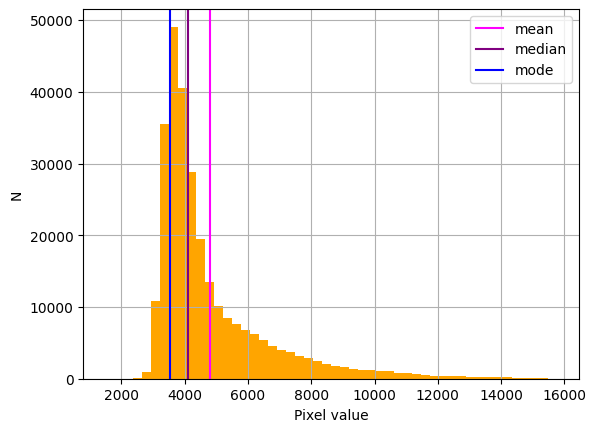

median: 4102.0


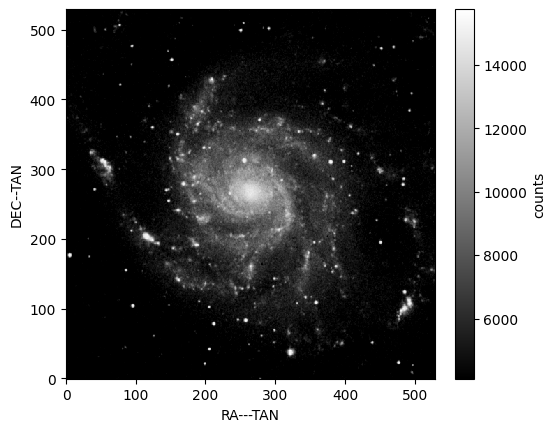

Description first axis: RA---TAN
Description second axis: DEC--TAN


 [astropy.io.fits.verify]


In [1]:
from astropy.io import fits
from scipy import stats
import numpy as np
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
import matplotlib


hdulist = fits.open('m101.fits')
hdulist.info()

#2HDU's
#PRIMARY HDU, at index 0
#int16


hdr = hdulist[0].header
for key in hdr[:5]:
    print(f"{key:18s}= {hdr[key]}")
#BITPIX=16, corresponds with datatype

#read the data
dat = hdulist[0].data

#print shape, it corresponds with the data
print(dat.shape)

print("This data structure is a:", type(dat))
print("Its shape should be (NAXIS2, NAXIS1):", (hdr['NAXIS2'], hdr['NAXIS1']) == dat.shape)  #corresponds with data

print(dat.dtype)
#>i2, > big endian, i integer, 2 bytes=16 bits, corresponds with 16int

#print statistical properties
flatdat = dat.flatten()
s = stats.describe(flatdat)
print(f"Statistics: {s}")
mode = stats.mode(dat.flat)
print(f"Mode={mode}")
print(f"Standard deviation of the data: {dat.std()}")
median = np.median(dat.flat)
print(f"Median of the data: {median}")
mean = np.mean(dat.flat)

#plot histogram
fig = figure()
frame = fig.add_subplot(1,1,1)
frame.hist(dat.flatten(), bins=50, color="orange")
frame.grid()
frame.set_xlabel("Pixel value")
frame.set_ylabel("N")
frame.axvline(mean, color='magenta', label='mean')
frame.axvline(median, color="purple", label='median')
frame.axvline(mode[0], color='blue', label='mode')
frame.legend()
show()

#convert data
arr=np.asarray(dat)

#print median
median_arr=np.median(arr)
print(f"median: {median}")

#plot the image data
fig = figure()
frame = fig.add_subplot(1,1,1)
imageObject=frame.imshow(dat, interpolation='none', origin="lower", cmap='gray',vmin=median_arr)
frame.set_xlabel("RA---TAN")
frame.set_ylabel("DEC--TAN")
fig.colorbar(imageObject, ax=frame, fraction=0.046, pad=0.04, label='counts')
show()

ctype1 = hdr['CTYPE1']
ctype2 = hdr['CTYPE2']
print("Description first axis:", ctype1)
print("Description second axis:", ctype2)

#add new keyword
hdr["BUNIT"] = "Counts"
#floating point version
logdat = np.log10(dat)
hdulistout = fits.PrimaryHDU(logdat)
hdulistout.header = hdr    # We can copy the old header
hdulistout.writeto('loghorsehead.fits', overwrite=True, output_verify='ignore')

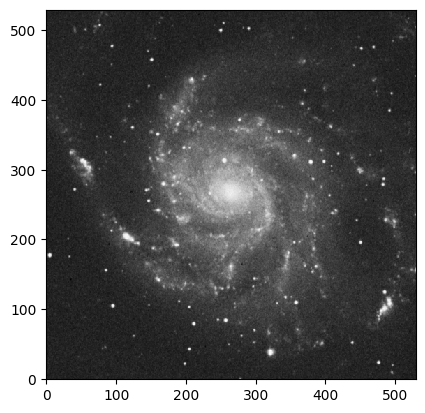

RMS: 271.89124664100535
mean: 3422.8825
standard deviation: 260.1300322795313


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from imageio import imread

hdulist = fits.open('m101.fits')

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.imshow(dat, interpolation='none', origin="lower", cmap='gray')
show()

x=dat[0:20, 0:20]

RMS=(np.sum(x**2)/len(x))**0.5

print(f"RMS: {RMS}")
mean=np.mean(x)
std=np.std(x)
print(f"mean: {mean}")
print(f"standard deviation: {std}")

#standard deviation is relative to the mean (x-mean), rms is relative to zero
#standard deviation is better because it shows the deviation and not with the mean included

standard deviation of noismap0.fits: 9.98401556679484 
standard deviation of noismap1.fits: 10.003955116338458 
standard deviation of noismap2.fits: 9.995349488722516 


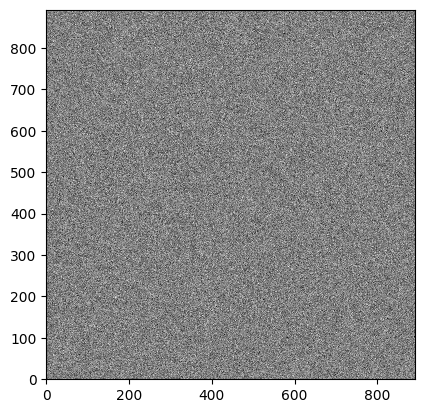

5.773191380233297
5.77029458336614


In [3]:
from astropy.io import fits
import numpy as np
from scipy import stats
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt

#download images
list0 = fits.open('noisemap0.fits')
list1 = fits.open('noisemap1.fits')
list2 = fits.open('noisemap2.fits')

#calculate standard deviation
dat0 = list0[0].data
dat1 = list1[0].data
dat2 = list2[0].data

std0= dat0.std()
std1= dat1.std()
std2= dat2.std()

print(f"standard deviation of noismap0.fits: {std0} ")
print(f"standard deviation of noismap1.fits: {std1} ")
print(f"standard deviation of noismap2.fits: {std2} ")

#stack the images
img_stack = np.stack([dat0, dat1, dat2], axis=0)

#calculate the mean
mean_img = np.mean(img_stack, axis=0)
#show image
fig = figure()
frame = fig.add_subplot(1,1,1)
frame.imshow(mean_img, interpolation='none', origin="lower", cmap='gray')
show()

#calculate the standard deviation
std_mean = np.std(mean_img)
print(std_mean)

#check the formula
std_formula=(std0**2 +std1**2 +std2**2)**0.5 /3
print(std_formula)

In [35]:
from astropy.io import fits
import numpy as np
from astropy.table import QTable

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')
# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

#difference between reading an image and table
    #image: simple grid of numbers
    #table: list of rows and columns
#diference in data structure
    #image: every spot in grid has same data (all numbers)
    #table: each column can have different type of data (numbers, names)

#create table
data = QTable(data)

#conditions
mask=(
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)

#create DATAFLAG
DATAFLAG = np.where(mask, 1, 0)

#add DATAFLAG to table
data['DATAFLAG'] = DATAFLAG

#calculate the absolute magnitude
m=data['GAIAEDR3_PHOT_G_MEAN_MAG']
p=data['GAIAEDR3_PARALLAX']

mask1=((p>0) & (~np.isnan(p)))
p_filtered= np.where(mask1, p, 1000)


abs_M =np.where(mask1, m + 5*np.log10(p_filtered/1000)+5, 'None')

#add the absolute magnitude to table
abs_M= np.where(DATAFLAG ==0, -1.0, abs_M)
data['ABSOLUTE MAGNITUDE'] = abs_M
print(data)
data.write('APOGEE_update.fits', overwrite=True)

GAIAEDR3_PARALLAX GAIAEDR3_PARALLAX_ERROR ... DATAFLAG ABSOLUTE MAGNITUDE
----------------- ----------------------- ... -------- ------------------
              nan                     nan ...        0               -1.0
       0.28544167                0.019475 ...        0               -1.0
       0.08209286                0.315081 ...        0               -1.0
        1.2985312              0.00952245 ...        0               -1.0
        1.2985312              0.00952245 ...        1          2.7881622
      -0.02394128               0.0450072 ...        0               -1.0
        1.3863556               0.0175672 ...        1          2.9852724
              ...                     ... ...      ...                ...
         4.132398                0.015343 ...        0               -1.0
      0.057267956               0.0597211 ...        0               -1.0
        1.4367273               0.0213831 ...        0               -1.0
       0.42296618               0.0192

maximum value: 42489404.0 
    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  


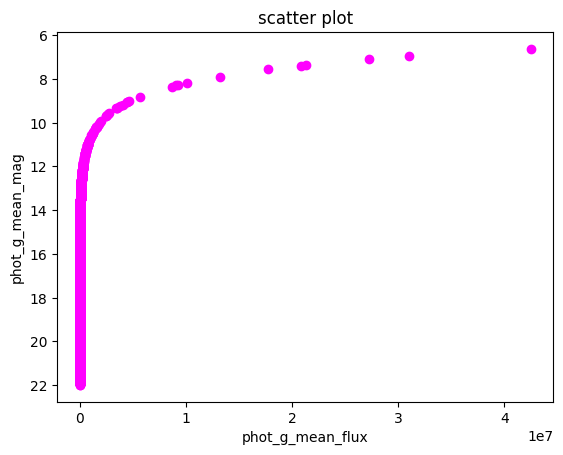

25.68840037029544


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

#create pandas dataframe
pdt = pd.read_csv('gaiaTestData.csv')

#find the maximum value
maximum= pdt.phot_g_mean_flux.max()
print(f"maximum value: {maximum} ")

max_row= pdt[pdt['phot_g_mean_flux']==maximum]

print(max_row)

#sort by column
pdt_sorted=pdt.sort_values(by='phot_g_mean_flux')

#scatter plot
fig = figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(pdt_sorted['phot_g_mean_flux'], pdt_sorted['phot_g_mean_mag'], color='magenta')
frame.set_xlabel("phot_g_mean_flux")
frame.set_ylabel("phot_g_mean_mag")
frame.set_title('scatter plot')
frame.invert_yaxis()
plt.show()

#calculate
m0= pdt['phot_g_mean_mag']+ 2.5* np.log10(pdt['phot_g_mean_flux'])
m0_avg= m0.mean()
print(m0_avg)

In [37]:
from astroquery.gaia import Gaia
import pandas as pd

query="""
SELECT TOP 50
    source_id,
    ra,
    dec,
    parallax,
    parallax_error,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax/ parallax_error > 5
    AND phot_g_mean_mag IS NOT NULL
    AND phot_bp_mean_mag IS NOT NULL
    AND phot_rp_mean_mag IS NOT NULL
ORDER BY random_index
"""
job = Gaia.launch_job(query)
results = job.get_results()

#create Pandas DataFrame
df_simple = results.to_pandas()

#create output file
results.write('astroquery_gaia.fits', overwrite=True)

#open the file
hdulist = fits.open('astroquery_gaia.fits')
dat = hdulist[1].data
print(dat)

[(4267180339403392768, 286.7169129 ,   0.2761946 , 1.08492386, 0.03343081, 15.244129 , 15.942071 , 14.419943 )
 (6709252873623174016, 276.69119392, -46.10512131, 0.20668183, 0.04010492, 15.840754 , 16.380306 , 15.151749 )
 (4040949706019490560, 265.22936348, -36.35820519, 0.35272487, 0.02966451, 14.802705 , 16.118845 , 13.680644 )
 (4517539583701880064, 284.02566216,  18.40303869, 0.67496243, 0.04000783, 16.073896 , 16.652264 , 15.347014 )
 (1823532754729083392, 300.80580445,  20.60100606, 0.88643505, 0.02005412, 14.375696 , 14.782262 , 13.795675 )
 (3586362911238437248, 171.80987738, -12.08680957, 7.19194838, 0.02249338, 13.987773 , 14.809981 , 12.990531 )
 (2220802729771409024, 320.39987162,  65.73495073, 0.28959899, 0.04491028, 16.704706 , 17.259604 , 15.978823 )
 (5850180760683762688, 205.69113799, -69.2587405 , 0.54108981, 0.08040186, 17.73207  , 18.26916  , 17.014418 )
 (2128624652762622080, 294.29627289,  47.56515893, 1.12442278, 0.09253254, 18.168076 , 19.113455 , 17.192604 )
 

In [8]:
class Fibonacci:
    def __init__(self, N, M):
        self.M = M
        self.N = N
    def fibo(self):
        fibonacci=[]
        a=0
        b=1
        c=0
        while len(fibonacci)<self.N:
            fibonacci.append(a)
            c=a+b
            a=b
            b=c
        return fibonacci

    def divide(self):
        filtered=[]
        for i in self.fibo():
            if i %self.M==0:
                filtered.append(i)
                
        return filtered
    
example=Fibonacci(100,7)
print(example.fibo())
print(example.divide())

[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181, 6765, 10946, 17711, 28657, 46368, 75025, 121393, 196418, 317811, 514229, 832040, 1346269, 2178309, 3524578, 5702887, 9227465, 14930352, 24157817, 39088169, 63245986, 102334155, 165580141, 267914296, 433494437, 701408733, 1134903170, 1836311903, 2971215073, 4807526976, 7778742049, 12586269025, 20365011074, 32951280099, 53316291173, 86267571272, 139583862445, 225851433717, 365435296162, 591286729879, 956722026041, 1548008755920, 2504730781961, 4052739537881, 6557470319842, 10610209857723, 17167680177565, 27777890035288, 44945570212853, 72723460248141, 117669030460994, 190392490709135, 308061521170129, 498454011879264, 806515533049393, 1304969544928657, 2111485077978050, 3416454622906707, 5527939700884757, 8944394323791464, 14472334024676221, 23416728348467685, 37889062373143906, 61305790721611591, 99194853094755497, 160500643816367088, 259695496911122585, 420196140727489673, 679891637638612258, 110008777